# A2.3 Modelos de ensamble, SVM y redes neuronales

**Materia:** Inteligencia Artificial  
**Alumno:** Emiliano Pascual Pinales Sanchez  
**Matrícula:** 657657  

## 1. Introducción

En esta actividad se continuará trabajando con los datos de la Encuesta Nacional de Ingresos y Gastos de los Hogares 2024 (ENIGH). El problema consiste en clasificar a los hogares según presenten un nivel de gasto corriente monetario bajo o alto.

El objetivo es construir y comparar modelos de clasificación más avanzados, específicamente Random Forest, Boosting, Support Vector Machine (SVM) y una red neuronal sencilla. Todos los modelos serán evaluados utilizando la misma partición de entrenamiento y prueba para poder comparar su desempeño de manera justa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Preparación del escenario experimental

Se utilizará el mismo conjunto de datos empleado en las actividades anteriores para mantener una comparación consistente. La variable objetivo será `gasto_alto`, donde 0 representa gasto bajo y 1 representa gasto alto.

Se conservará la misma división de 80 % para entrenamiento y 20 % para prueba, utilizando una separación estratificada y `random_state=42`.

In [2]:
df = pd.read_csv(
    "concentradohogar.csv",
    dtype={
        "folioviv": str,
        "foliohog": str,
        "ubica_geo": str,
        "est_dis": str,
        "upm": str
    },
    low_memory=False
)

print("Base de datos cargada correctamente.")
print("Número de hogares:", df.shape[0])
print("Número de variables:", df.shape[1])

Base de datos cargada correctamente.
Número de hogares: 91414
Número de variables: 126


In [3]:
df = df.copy()

mediana_gasto = df["gasto_mon"].median()

df["gasto_alto"] = (
    df["gasto_mon"] > mediana_gasto
).astype(int)

balance_clases = pd.DataFrame({
    "Frecuencia": df["gasto_alto"].value_counts().sort_index(),
    "Porcentaje": df["gasto_alto"].value_counts(
        normalize=True
    ).sort_index() * 100
})

balance_clases.index = [
    "Gasto bajo (0)",
    "Gasto alto (1)"
]

print(f"Mediana del gasto: ${mediana_gasto:,.2f}")

balance_clases

Mediana del gasto: $34,182.51


,Frecuencia,Porcentaje
Gasto bajo (0),45707,50.0
Gasto alto (1),45707,50.0


In [4]:
df["ingreso_log"] = np.log1p(df["ing_cor"])

variables_numericas = [
    "ingreso_log",
    "tot_integ",
    "ocupados",
    "percep_ing",
    "edad_jefe"
]

variables_categoricas = [
    "educa_jefe",
    "sexo_jefe",
    "tam_loc",
    "est_socio",
    "clase_hog"
]

variables_modelo = (
    variables_numericas
    + variables_categoricas
)

X = df[variables_modelo].copy()
y = df["gasto_alto"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (73131, 10)
Prueba: (18283, 10)


## Metodología

Para todos los modelos se utilizó la misma partición estratificada de entrenamiento y prueba. Las variables numéricas y categóricas fueron preparadas de acuerdo con las necesidades de cada algoritmo. Los hiperparámetros utilizados se seleccionaron buscando configuraciones razonables y sencillas, sin realizar una optimización exhaustiva, con el propósito de comparar el comportamiento de los diferentes enfoques bajo condiciones consistentes.

## 3. Random Forest

El primer modelo utilizado será Random Forest, un método de ensamble que combina múltiples árboles de decisión. Cada árbol realiza una predicción y el resultado final se obtiene a partir de la decisión conjunta del conjunto de árboles.

Se utilizarán 200 árboles con `random_state=42` para obtener resultados reproducibles. También se limitará la profundidad y el tamaño mínimo de las hojas para controlar la complejidad del modelo y reducir el riesgo de sobreajuste.

In [5]:
pipeline_numerico = Pipeline([
    ("imputacion", SimpleImputer(strategy="median"))
])

pipeline_categorico = Pipeline([
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocesamiento_rf = ColumnTransformer([
    (
        "numericas",
        pipeline_numerico,
        variables_numericas
    ),
    (
        "categoricas",
        pipeline_categorico,
        variables_categoricas
    )
])

modelo_rf = Pipeline([
    ("preprocesamiento", preprocesamiento_rf),
    (
        "modelo",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )
    )
])

print("Random Forest preparado correctamente.")

Random Forest preparado correctamente.


In [6]:
modelo_rf.fit(X_train, y_train)

print("Random Forest entrenado correctamente.")

Random Forest entrenado correctamente.


In [7]:
pred_rf = modelo_rf.predict(X_test)
prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

resultados_rf = {
    "Modelo": "Random Forest",
    "Accuracy": accuracy_score(y_test, pred_rf),
    "Precision": precision_score(y_test, pred_rf),
    "Recall": recall_score(y_test, pred_rf),
    "F1-score": f1_score(y_test, pred_rf),
    "ROC-AUC": roc_auc_score(y_test, prob_rf)
}

pd.DataFrame([resultados_rf]).round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.7836,0.7785,0.7928,0.7856,0.8675


## 4. Boosting

El segundo modelo será Gradient Boosting. Este método de ensamble construye árboles de manera secuencial, donde cada nuevo árbol intenta corregir los errores cometidos por los anteriores.

Se utilizarán 100 estimadores, una tasa de aprendizaje de 0.05 y una profundidad máxima de 3. Estos valores permiten mantener un equilibrio entre capacidad predictiva y complejidad sin realizar una búsqueda exhaustiva de hiperparámetros.

In [8]:
preprocesamiento_boost = ColumnTransformer([
    (
        "numericas",
        Pipeline([
            ("imputacion", SimpleImputer(strategy="median"))
        ]),
        variables_numericas
    ),
    (
        "categoricas",
        Pipeline([
            ("imputacion", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]),
        variables_categoricas
    )
])

modelo_boost = Pipeline([
    ("preprocesamiento", preprocesamiento_boost),
    (
        "modelo",
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])

print("Boosting preparado correctamente.")

Boosting preparado correctamente.


In [9]:
modelo_boost.fit(X_train, y_train)

print("Boosting entrenado correctamente.")

Boosting entrenado correctamente.


In [10]:
pred_boost = modelo_boost.predict(X_test)
prob_boost = modelo_boost.predict_proba(X_test)[:, 1]

resultados_boost = {
    "Modelo": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test, pred_boost),
    "Precision": precision_score(y_test, pred_boost),
    "Recall": recall_score(y_test, pred_boost),
    "F1-score": f1_score(y_test, pred_boost),
    "ROC-AUC": roc_auc_score(y_test, prob_boost)
}

pd.DataFrame([resultados_boost]).round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gradient Boosting,0.7829,0.7788,0.7902,0.7844,0.8672


## 5. Support Vector Machine (SVM)

El tercer modelo será una máquina de soporte vectorial. Debido al tamaño del conjunto de datos, se utilizará una SVM con frontera lineal, lo cual permite trabajar de manera eficiente con una cantidad grande de observaciones.

Las variables numéricas serán estandarizadas y las variables categóricas se transformarán mediante codificación one-hot. Se utilizará `C=1.0` como valor regular de penalización, buscando un equilibrio entre el ajuste a los datos y la complejidad de la frontera de decisión.

In [11]:
from sklearn.svm import LinearSVC

preprocesamiento_svm = ColumnTransformer([
    (
        "numericas",
        Pipeline([
            ("imputacion", SimpleImputer(strategy="median")),
            ("escalado", StandardScaler())
        ]),
        variables_numericas
    ),
    (
        "categoricas",
        Pipeline([
            ("imputacion", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]),
        variables_categoricas
    )
])

modelo_svm = Pipeline([
    ("preprocesamiento", preprocesamiento_svm),
    (
        "modelo",
        LinearSVC(
            C=1.0,
            max_iter=10000,
            random_state=42
        )
    )
])

print("SVM preparado correctamente.")

SVM preparado correctamente.


In [12]:
modelo_svm.fit(X_train, y_train)

print("SVM entrenado correctamente.")

SVM entrenado correctamente.


In [13]:
pred_svm = modelo_svm.predict(X_test)
score_svm = modelo_svm.decision_function(X_test)

resultados_svm = {
    "Modelo": "SVM lineal",
    "Accuracy": accuracy_score(y_test, pred_svm),
    "Precision": precision_score(y_test, pred_svm),
    "Recall": recall_score(y_test, pred_svm),
    "F1-score": f1_score(y_test, pred_svm),
    "ROC-AUC": roc_auc_score(y_test, score_svm)
}

pd.DataFrame([resultados_svm]).round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM lineal,0.7803,0.7774,0.7857,0.7815,0.8662


## 6. Red neuronal construida desde cero

El cuarto modelo será una red neuronal sencilla implementada directamente con NumPy, sin utilizar un clasificador de redes neuronales ya construido.

La arquitectura tendrá una capa de entrada, una capa oculta de 8 neuronas con activación ReLU y una neurona de salida con activación sigmoide para realizar clasificación binaria. Los datos numéricos serán estandarizados y las variables categóricas serán codificadas mediante one-hot.

El entrenamiento se realizará mediante descenso de gradiente en mini-lotes. Se utilizarán parámetros moderados para mantener una red sencilla y reducir el riesgo de sobreajuste.

In [14]:
preprocesamiento_nn = ColumnTransformer([
    (
        "numericas",
        Pipeline([
            ("imputacion", SimpleImputer(strategy="median")),
            ("escalado", StandardScaler())
        ]),
        variables_numericas
    ),
    (
        "categoricas",
        Pipeline([
            ("imputacion", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]),
        variables_categoricas
    )
])

X_train_nn = preprocesamiento_nn.fit_transform(X_train)
X_test_nn = preprocesamiento_nn.transform(X_test)

X_train_nn = X_train_nn.astype(np.float32)
X_test_nn = X_test_nn.astype(np.float32)

y_train_nn = y_train.to_numpy().reshape(-1, 1).astype(np.float32)
y_test_nn = y_test.to_numpy().reshape(-1, 1).astype(np.float32)

print("Entrenamiento:", X_train_nn.shape)
print("Prueba:", X_test_nn.shape)

Entrenamiento: (73131, 31)
Prueba: (18283, 31)


In [15]:
np.random.seed(42)

n_entrada = X_train_nn.shape[1]
n_oculta = 8

W1 = (
    np.random.randn(n_entrada, n_oculta)
    * np.sqrt(2 / n_entrada)
).astype(np.float32)

b1 = np.zeros((1, n_oculta), dtype=np.float32)

W2 = (
    np.random.randn(n_oculta, 1)
    * np.sqrt(2 / n_oculta)
).astype(np.float32)

b2 = np.zeros((1, 1), dtype=np.float32)


def relu(z):
    return np.maximum(0, z)


def sigmoid(z):
    z = np.clip(z, -30, 30)
    return 1 / (1 + np.exp(-z))


def forward(X):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    return Z1, A1, A2


print("Red neuronal inicializada correctamente.")

Red neuronal inicializada correctamente.


In [16]:
learning_rate = 0.01
epochs = 25
batch_size = 512

n = X_train_nn.shape[0]

for epoch in range(epochs):

    indices = np.random.permutation(n)
    X_barajado = X_train_nn[indices]
    y_barajado = y_train_nn[indices]

    for inicio in range(0, n, batch_size):

        fin = inicio + batch_size

        X_batch = X_barajado[inicio:fin]
        y_batch = y_barajado[inicio:fin]

        m = X_batch.shape[0]

        Z1, A1, A2 = forward(X_batch)

        dZ2 = A2 - y_batch
        dW2 = (A1.T @ dZ2) / m
        db2 = np.mean(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * (Z1 > 0)

        dW1 = (X_batch.T @ dZ1) / m
        db1 = np.mean(dZ1, axis=0, keepdims=True)

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    _, _, prob_train = forward(X_train_nn)

    prob_train_segura = np.clip(
        prob_train,
        1e-7,
        1 - 1e-7
    )

    perdida = -np.mean(
        y_train_nn * np.log(prob_train_segura)
        + (1 - y_train_nn)
        * np.log(1 - prob_train_segura)
    )

    if (epoch + 1) % 5 == 0:
        print(
            f"Época {epoch + 1:2d}/{epochs} "
            f"- Pérdida: {perdida:.4f}"
        )

print("Red neuronal entrenada correctamente.")

Época  5/25 - Pérdida: 0.5030
Época 10/25 - Pérdida: 0.4709
Época 15/25 - Pérdida: 0.4625
Época 20/25 - Pérdida: 0.4589
Época 25/25 - Pérdida: 0.4570
Red neuronal entrenada correctamente.


In [17]:
_, _, prob_nn = forward(X_test_nn)

pred_nn = (prob_nn >= 0.5).astype(int).ravel()
prob_nn = prob_nn.ravel()

resultados_nn = {
    "Modelo": "Red neuronal",
    "Accuracy": accuracy_score(y_test, pred_nn),
    "Precision": precision_score(y_test, pred_nn),
    "Recall": recall_score(y_test, pred_nn),
    "F1-score": f1_score(y_test, pred_nn),
    "ROC-AUC": roc_auc_score(y_test, prob_nn)
}

pd.DataFrame([resultados_nn]).round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Red neuronal,0.7788,0.7799,0.7767,0.7783,0.8635


## 7. Comparación de resultados

Los cuatro modelos fueron evaluados sobre el mismo conjunto de prueba utilizando accuracy, precision, recall, F1-score y ROC-AUC. Esto permite comparar su comportamiento bajo las mismas condiciones experimentales.

In [18]:
comparacion = pd.DataFrame([
    resultados_rf,
    resultados_boost,
    resultados_svm,
    resultados_nn
])

comparacion.set_index("Modelo").round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
Random Forest,0.7836,0.7785,0.7928,0.7856,0.8675
Gradient Boosting,0.7829,0.7788,0.7902,0.7844,0.8672
SVM lineal,0.7803,0.7774,0.7857,0.7815,0.8662
Red neuronal,0.7788,0.7799,0.7767,0.7783,0.8635


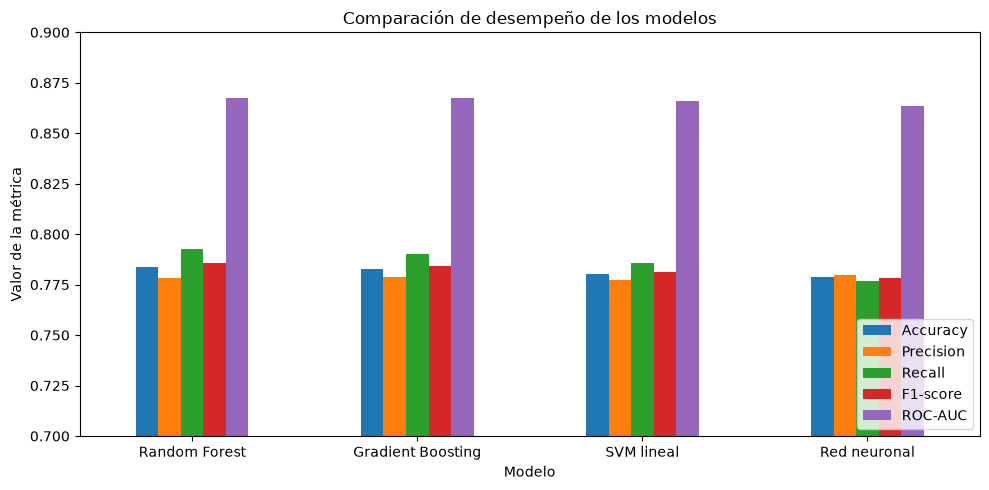

In [19]:
comparacion_grafica = comparacion.set_index("Modelo")[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
]

comparacion_grafica.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparación de desempeño de los modelos")
plt.ylabel("Valor de la métrica")
plt.ylim(0.70, 0.90)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import roc_curve

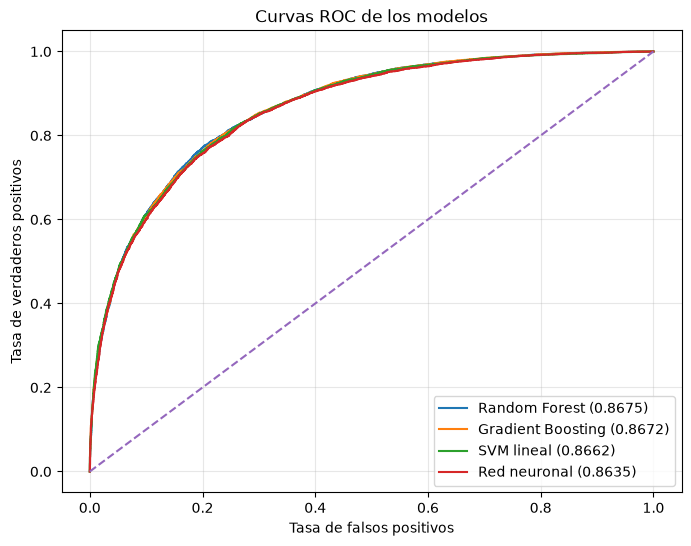

In [21]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
fpr_boost, tpr_boost, _ = roc_curve(y_test, prob_boost)
fpr_svm, tpr_svm, _ = roc_curve(y_test, score_svm)
fpr_nn, tpr_nn, _ = roc_curve(y_test, prob_nn)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf, tpr_rf,
    label=f"Random Forest ({resultados_rf['ROC-AUC']:.4f})"
)

plt.plot(
    fpr_boost, tpr_boost,
    label=f"Gradient Boosting ({resultados_boost['ROC-AUC']:.4f})"
)

plt.plot(
    fpr_svm, tpr_svm,
    label=f"SVM lineal ({resultados_svm['ROC-AUC']:.4f})"
)

plt.plot(
    fpr_nn, tpr_nn,
    label=f"Red neuronal ({resultados_nn['ROC-AUC']:.4f})"
)

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC de los modelos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Análisis de sobreajuste

Para revisar si alguno de los modelos presenta señales de sobreajuste, se comparará su desempeño en los conjuntos de entrenamiento y prueba. Una diferencia considerable entre ambos podría indicar que el modelo aprendió demasiado específicamente los datos de entrenamiento.

In [22]:
# Random Forest
pred_rf_train = modelo_rf.predict(X_train)

# Gradient Boosting
pred_boost_train = modelo_boost.predict(X_train)

# SVM
pred_svm_train = modelo_svm.predict(X_train)

# Red neuronal
_, _, prob_nn_train = forward(X_train_nn)
pred_nn_train = (prob_nn_train >= 0.5).astype(int).ravel()

comparacion_sobreajuste = pd.DataFrame({
    "Modelo": [
        "Random Forest",
        "Gradient Boosting",
        "SVM lineal",
        "Red neuronal"
    ],
    "Accuracy entrenamiento": [
        accuracy_score(y_train, pred_rf_train),
        accuracy_score(y_train, pred_boost_train),
        accuracy_score(y_train, pred_svm_train),
        accuracy_score(y_train, pred_nn_train)
    ],
    "Accuracy prueba": [
        resultados_rf["Accuracy"],
        resultados_boost["Accuracy"],
        resultados_svm["Accuracy"],
        resultados_nn["Accuracy"]
    ],
    "F1 entrenamiento": [
        f1_score(y_train, pred_rf_train),
        f1_score(y_train, pred_boost_train),
        f1_score(y_train, pred_svm_train),
        f1_score(y_train, pred_nn_train)
    ],
    "F1 prueba": [
        resultados_rf["F1-score"],
        resultados_boost["F1-score"],
        resultados_svm["F1-score"],
        resultados_nn["F1-score"]
    ]
})

comparacion_sobreajuste.round(4)

,Modelo,Accuracy entrenamiento,Accuracy prueba,F1 entrenamiento,F1 prueba
0,Random Forest,0.8062,0.7836,0.8085,0.7856
1,Gradient Boosting,0.7888,0.7829,0.7910,0.7844
2,SVM lineal,0.7872,0.7803,0.7881,0.7815
3,Red neuronal,0.7847,0.7788,0.7851,0.7783


### Matrices de confusión

Las matrices de confusión permiten observar la cantidad de hogares clasificados correctamente y los errores cometidos por cada modelo para las clases de gasto bajo y gasto alto.

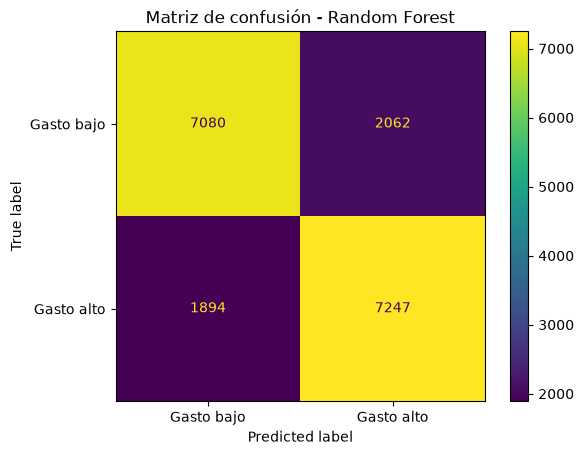

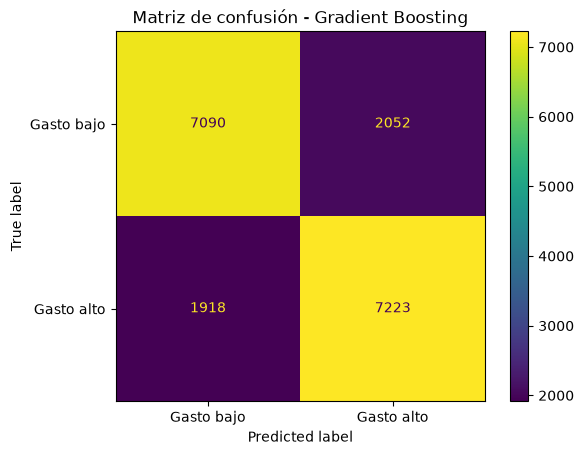

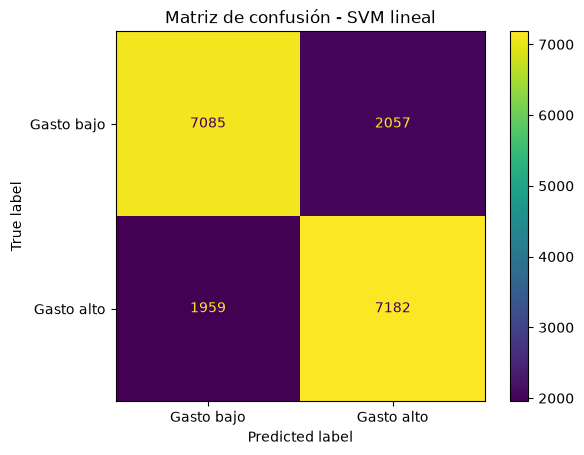

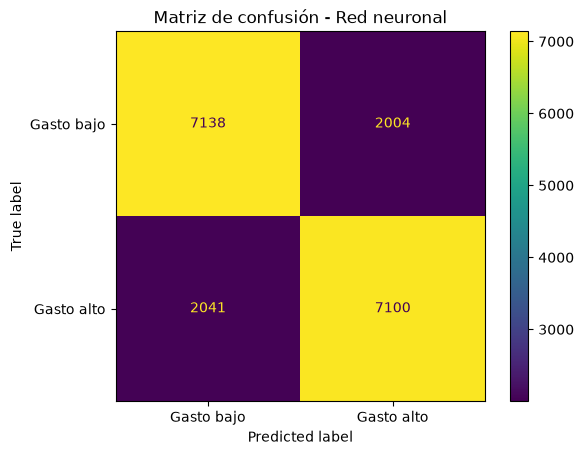

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

modelos_predicciones = [
    ("Random Forest", pred_rf),
    ("Gradient Boosting", pred_boost),
    ("SVM lineal", pred_svm),
    ("Red neuronal", pred_nn)
]

for nombre, predicciones in modelos_predicciones:
    matriz = confusion_matrix(y_test, predicciones)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=["Gasto bajo", "Gasto alto"]
    )

    disp.plot()
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

## 9. Análisis crítico de los resultados

Los cuatro modelos presentaron un desempeño similar. Random Forest obtuvo un accuracy de 0.7836, un F1-score de 0.7856 y un ROC-AUC de 0.8675. Gradient Boosting obtuvo valores muy cercanos, con un accuracy de 0.7829, F1-score de 0.7844 y ROC-AUC de 0.8672. El SVM lineal alcanzó un accuracy de 0.7803 y la red neuronal un accuracy de 0.7788.

Las diferencias entre los modelos son pequeñas, por lo que el aumento en complejidad no produjo una mejora sustancial en la capacidad predictiva. Random Forest presentó los valores más altos en varias métricas, pero la ventaja frente a Gradient Boosting, SVM y la red neuronal fue marginal.

Al comparar entrenamiento y prueba, Random Forest presentó la mayor diferencia, con accuracy de 0.8062 en entrenamiento y 0.7836 en prueba. Esto indica una ligera señal de sobreajuste, aunque la diferencia no es extrema. Los demás modelos mostraron diferencias menores, lo que indica un comportamiento más estable.

En cuanto a interpretabilidad, Random Forest y Gradient Boosting son más complejos que un modelo lineal debido a que combinan múltiples árboles. El SVM lineal permite una frontera de decisión más sencilla, mientras que la red neuronal es menos interpretable porque sus decisiones dependen de pesos internos distribuidos entre las neuronas.

Los resultados muestran que una mayor complejidad no necesariamente produce una mejora importante. La elección del modelo dependería también de factores como interpretabilidad, costo computacional y estabilidad, además de las métricas de desempeño.

## 10. Conclusión

En esta actividad se entrenaron y compararon cuatro modelos avanzados de clasificación utilizando el mismo conjunto de datos de la ENIGH 2024 y la misma partición de entrenamiento y prueba.

Random Forest, Gradient Boosting, SVM y la red neuronal lograron resultados similares. Random Forest presentó los valores más altos de accuracy, F1-score y ROC-AUC, aunque las diferencias respecto a los demás modelos fueron pequeñas. Por esta razón, no se observa una mejora sustancial asociada únicamente al aumento de complejidad.

El análisis de entrenamiento y prueba mostró que Random Forest presenta una ligera tendencia al sobreajuste, mientras que los otros modelos mantienen diferencias menores entre ambos conjuntos. La red neuronal construida desde cero logró un desempeño competitivo, aunque no superó a los métodos de ensamble en este problema.

En general, los resultados muestran que cada enfoque tiene ventajas y limitaciones. Los métodos de ensamble ofrecen una buena capacidad predictiva, el SVM proporciona una alternativa más sencilla y estable, y la red neuronal permite representar relaciones más complejas a cambio de una menor interpretabilidad. Por lo tanto, la selección de un modelo debe considerar no solamente su desempeño, sino también su complejidad, estabilidad e interpretabilidad.